###Adaboost Demo

In [3]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [4]:
df = pd.DataFrame()

In [5]:
data = {
    'X1': [1,2,3,4,5,6,6,7,9,9],
    'X2': [5,3,6,8,1,9,5,8,9,2],
    'label': [1,1,0,1,0,1,0,1,0,0]
}
df = pd.DataFrame(data)

In [6]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

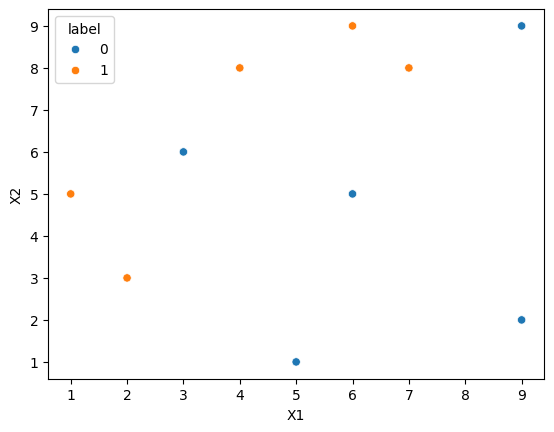

In [7]:
import seaborn as sns
sns.scatterplot(x = df['X1'] , y = df['X2'] , hue = df['label'])

In [8]:
df['weights'] = 1/df.shape[0]

In [9]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [10]:
from sklearn.tree import DecisionTreeClassifier

In [11]:
dt1 = DecisionTreeClassifier(max_depth = 1)

In [12]:
X = df.iloc[: , 0:2].values
y = df.iloc[: ,2].values

In [13]:
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

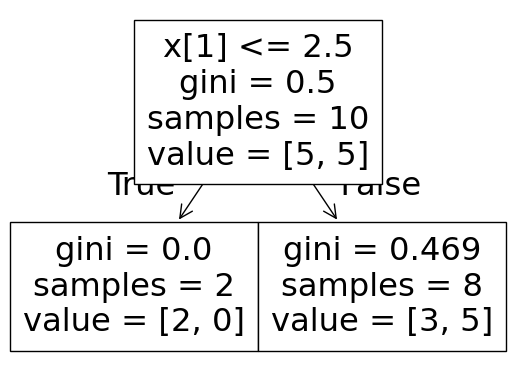

In [14]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

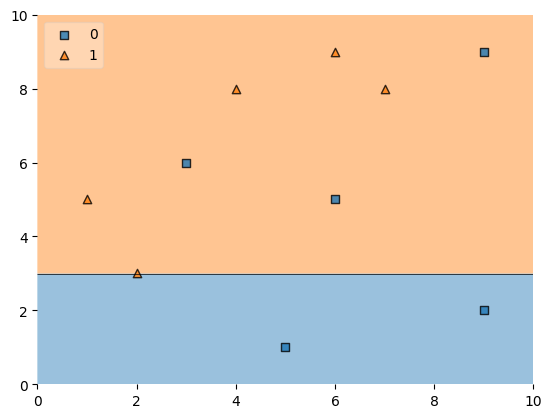

In [15]:
plot_decision_regions(X , y , clf = dt1 , legend = 2)

In [16]:
df['y_pred'] = dt1.predict(X)

In [17]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [19]:
def calculate_model_weight(error):
  return 0.5*np.log((1-error)/(error))

In [21]:
#now calculate model weight
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [22]:
#update the weights
def update_row_weights(row , alpha = 0.423):
  if row['label'] == row['y_pred']:
    return row['weights']*np.exp(-alpha)
  else:
    return row['weights']*np.exp(alpha)

In [23]:
df['updated_weights'] = df.apply(update_row_weights , axis = 1)

In [24]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [25]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [26]:
df['normalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [27]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [28]:
df['normalized_weights'].sum()

np.float64(1.0)

In [29]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])

In [30]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

In [31]:
df[['X1' , 'X2' , 'label' , 'weights' , 'y_pred' , 'updated_weights' , 'cumsum_lower' , 'cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [33]:
def create_new_dataset(df):
  indices = []
  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a>row['cumsum_lower'] :
        indices.append(index)
  return indices

In [35]:
index_values = create_new_dataset(df)
index_values

[6, 4, 4, 5, 8, 0, 2, 5, 7, 1]

In [37]:
second_df = df.iloc[index_values , [0,1,2,3]]
second_df

,X1,X2,label,weights
6,6,5,0,0.1
4,5,1,0,0.1
4,5,1,0,0.1
5,6,9,1,0.1
8,9,9,0,0.1
0,1,5,1,0.1
2,3,6,0,0.1
5,6,9,1,0.1
7,7,8,1,0.1
1,2,3,1,0.1


In [38]:
dt2 = DecisionTreeClassifier(max_depth = 1)


In [39]:
X = second_df.iloc[: , 0:2].values
y = second_df.iloc[: , 2].values

In [40]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

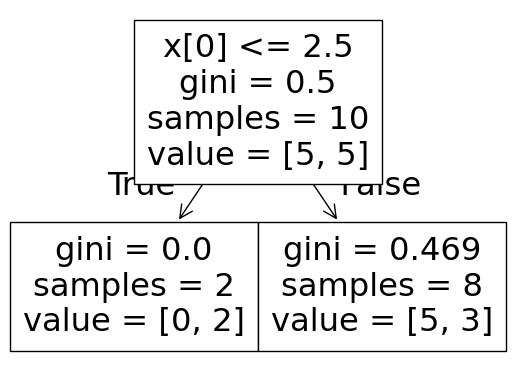

In [41]:
plot_tree(dt2)

<Axes: >

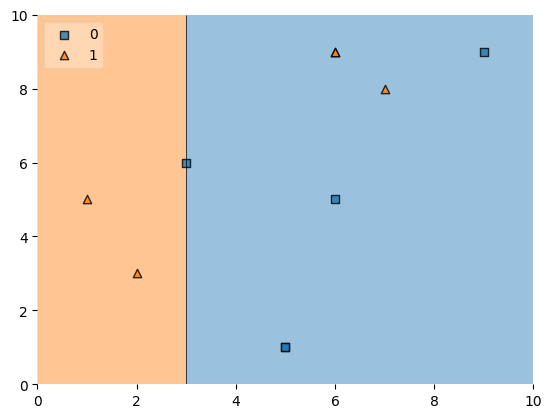

In [42]:
plot_decision_regions(X , y , clf = dt2 , legend = 2)

In [43]:
second_df['y_pred'] = dt2.predict(X)

In [44]:
second_df

,X1,X2,label,weights,y_pred
6,6,5,0,0.1,0
4,5,1,0,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
8,9,9,0,0.1,0
0,1,5,1,0.1,1
2,3,6,0,0.1,0
5,6,9,1,0.1,0
7,7,8,1,0.1,0
1,2,3,1,0.1,1


In [45]:
alpha2 = calculate_model_weight(0.1)


In [46]:
alpha2

np.float64(1.0986122886681098)

In [47]:
def update_row_weights(row , alpha  = 1.09):
  if row['label'] == row['y_pred']:
    return row['weights']*np.exp(-alpha)
  else :
    return row['weights']*np.exp(alpha)

In [48]:
second_df['updated_weights'] = second_df.apply(update_row_weights , axis = 1)

In [49]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
6,6,5,0,0.1,0,0.033622
4,5,1,0,0.1,0,0.033622
4,5,1,0,0.1,0,0.033622
5,6,9,1,0.1,0,0.297427
8,9,9,0,0.1,0,0.033622
0,1,5,1,0.1,1,0.033622
2,3,6,0,0.1,0,0.033622
5,6,9,1,0.1,0,0.297427
7,7,8,1,0.1,0,0.297427
1,2,3,1,0.1,1,0.033622


In [50]:
second_df['normalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [51]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
6,6,5,0,0.1,0,0.033622,0.029816
4,5,1,0,0.1,0,0.033622,0.029816
4,5,1,0,0.1,0,0.033622,0.029816
5,6,9,1,0.1,0,0.297427,0.263762
8,9,9,0,0.1,0,0.033622,0.029816
0,1,5,1,0.1,1,0.033622,0.029816
2,3,6,0,0.1,0,0.033622,0.029816
5,6,9,1,0.1,0,0.297427,0.263762
7,7,8,1,0.1,0,0.297427,0.263762
1,2,3,1,0.1,1,0.033622,0.029816


In [52]:
second_df['normalized_weights'].sum()

np.float64(1.0)

In [53]:
second_df['cumsum_upper'] = np.cumsum(second_df['normalized_weights'])

In [54]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['normalized_weights']

In [55]:
second_df[['X1' , 'X2' , 'label' , 'weights' , 'y_pred' , 'updated_weights' , 'cumsum_lower' , 'cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
6,6,5,0,0.1,0,0.033622,0.000000,0.029816
4,5,1,0,0.1,0,0.033622,0.029816,0.059632
4,5,1,0,0.1,0,0.033622,0.059632,0.089448
5,6,9,1,0.1,0,0.297427,0.089448,0.353211
8,9,9,0,0.1,0,0.033622,0.353211,0.383027
0,1,5,1,0.1,1,0.033622,0.383027,0.412843
2,3,6,0,0.1,0,0.033622,0.412843,0.442659
5,6,9,1,0.1,0,0.297427,0.442659,0.706421
7,7,8,1,0.1,0,0.297427,0.706421,0.970184
1,2,3,1,0.1,1,0.033622,0.970184,1.000000


In [56]:
index_values = create_new_dataset(second_df)

In [57]:
third_df = second_df.iloc[index_values , [0,1,2,3]]
third_df

,X1,X2,label,weights
0,1,5,1,0.1
0,1,5,1,0.1
0,1,5,1,0.1
6,6,5,0,0.1
0,1,5,1,0.1
4,5,1,0,0.1
4,5,1,0,0.1
0,1,5,1,0.1
5,6,9,1,0.1
6,6,5,0,0.1


In [58]:
dt3 = DecisionTreeClassifier(max_depth = 1)
X = second_df.iloc[: , 0:2].values
y = second_df.iloc[: , 2].values
dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

<Axes: >

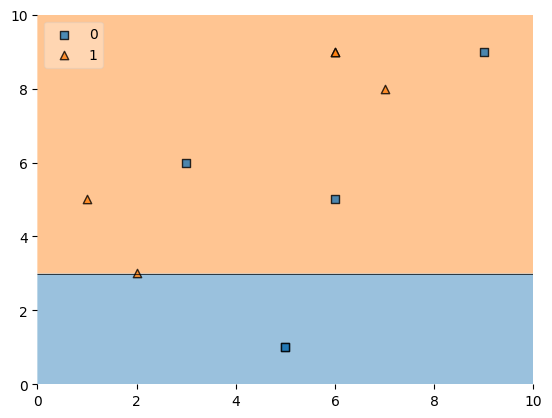

In [59]:
plot_decision_regions(X , y , clf = dt3 , legend = 2)

In [60]:
third_df['y_pred'] = dt3.predict(X)

In [61]:
third_df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
0,1,5,1,0.1,0
0,1,5,1,0.1,0
6,6,5,0,0.1,1
0,1,5,1,0.1,1
4,5,1,0,0.1,1
4,5,1,0,0.1,1
0,1,5,1,0.1,1
5,6,9,1,0.1,1
6,6,5,0,0.1,1


In [62]:
alpha3 = calculate_model_weight(0.7)
alpha3

np.float64(-0.4236489301936017)

In [63]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 1.0986122886681098 -0.4236489301936017


###Prediction


In [65]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [66]:
dt2.predict(query)

array([1])

In [67]:
dt3.predict(query)

array([1])

In [68]:
alpha1*1 + alpha2*(1) + alpha3*(1)

np.float64(1.09861228866811)

In [70]:
np.sign(1.09)

np.float64(1.0)

In [71]:
query = np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([1])

In [72]:
dt2.predict(query)

array([0])

In [73]:
dt3.predict(query)

array([1])

In [74]:
alpha1*(1) + alpha2*(-1) + alpha3*(-1)

np.float64(-0.2513144282809062)

In [75]:
np.sign(-0.25)

np.float64(-1.0)